# Customer Segmentation — Unsupervised Learning Project


## Project Structure
- **Section 1** — Data loading, cleaning, feature selection & outlier removal
- **Section 2** — Finding optimal K (Elbow + Silhouette + Davies-Bouldin)
- **Section 3** — Clustering, profiling & naming segments
- **Section 4** — Visualizations (PCA, bar charts, boxplots)
- **Section 5** — Decision Tree to classify new customers
-**Section 6** —  Recommendations, Strategy per segment, CLV-informed priorities, Churn risk actions  
-**Section 7** — Predictor, Single customer prediction, Batch prediction (Excel)

---
## Section 1 — Setup, Data Loading & Preprocessing

In [1]:
# ── 1.1 Import all required libraries ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [2]:
# ── 1.2 Load the dataset ───────────────────────────────────────────────────────
df = pd.read_excel('RetailX_cleaned.xlsx')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (2000, 16)
Columns: ['Cust_No', 'avg_order_size', 'avg_order_freq', 'crossbuy', 'multichannel', 'per_sale', 'tenure', 'return_rate', 'married', 'own_home', 'household_size', 'loyalty_card', 'income', 'age', 'avg_mktg_cnt', 'zip_code']


,Cust_No,avg_order_size,avg_order_freq,crossbuy,multichannel,per_sale,tenure,return_rate,married,own_home,household_size,loyalty_card,income,age,avg_mktg_cnt,zip_code
0,1,23.400000,2.222222,3,2,0.000000,3,0.117521,1,1,1,1,35,47,56.000000,21230
1,2,34.260377,6.625000,7,2,0.111111,35,0.281868,1,1,3,1,140,70,14.914286,22301
2,3,43.575641,4.875000,5,2,0.074074,12,0.274177,1,0,4,0,35,21,20.083333,19002
3,4,26.316667,0.900000,4,2,0.250000,9,0.143551,0,0,1,1,35,62,8.222222,22304
4,5,8.269231,1.083333,3,1,0.500000,40,0.000000,0,0,2,0,140,21,1.350000,20124


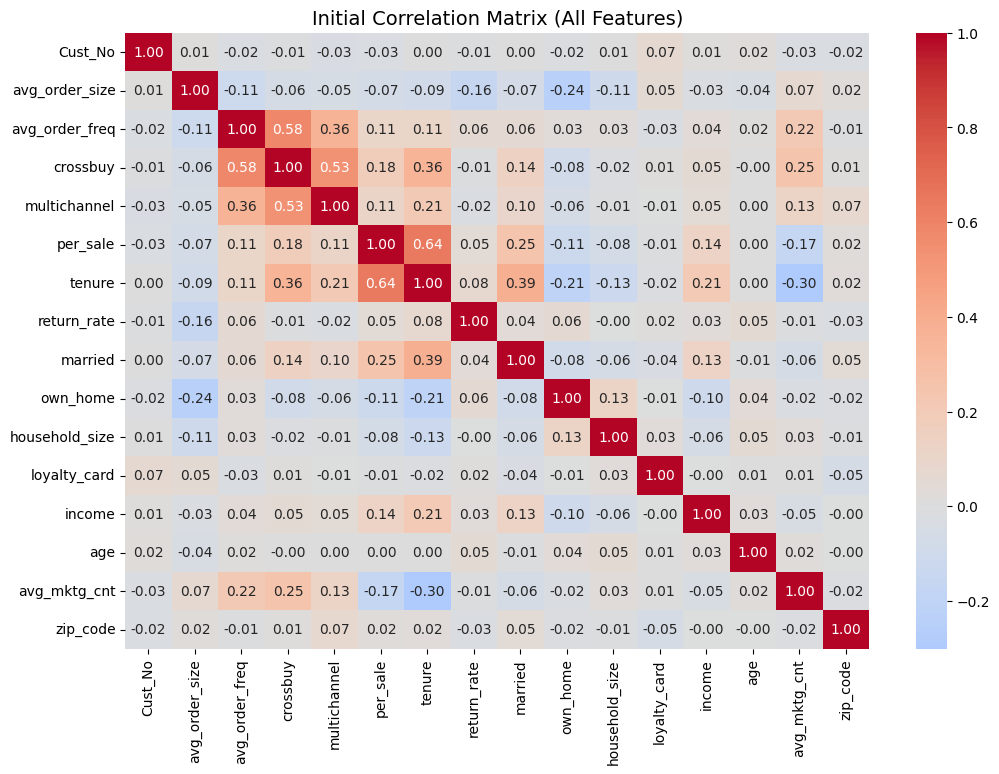

In [3]:
# ── 1.2.1 Correlation Analysis (Justifying Feature Selection) ───────────────

# Before we select our features, we check how they relate to each other.
# To avoid "Multicollinearity" (redundant features) because:
# 1. It gives too much weight to the same underlying behavior.
# 2. It makes the model less efficient.

# We'll look for correlations > 0.6 to decide what to drop.


plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Initial Correlation Matrix (All Features)', fontsize=14)
plt.show()

In [4]:
# ── 1.3 Feature Selection ──────────────────────────────────────────────────────
#
# After correlation analysis, we keep only BEHAVIORAL features that:
#   (a) have meaningful variance
#   (b) are NOT redundant with each other (correlation < 0.6)
#
# DROPPED features and reasons:
#   - Cust_No, zip_code  → identifiers, no signal
#   - per_sale           → near-zero variance (median = 0), redundant with tenure (r=0.64)
#   - loyalty_card       → strongly redundant with crossbuy (r=0.73)
#   - return_rate        → correlates with almost nothing (noise)
#   - married, own_home, age, household_size → demographic noise, weak signal across all features

SELECTED_FEATURES = [
    'avg_order_size',   # How much a customer spends per order
    'avg_order_freq',   # How often they order
    'crossbuy',         # Number of different product categories purchased
    'multichannel',     # Number of channels used
    'tenure',           # How long they have been a customer
    'income',           # Customer income
    'avg_mktg_cnt'      # Average marketing contacts received
]

features = df[SELECTED_FEATURES].copy()
print(f'Selected {len(SELECTED_FEATURES)} features: {SELECTED_FEATURES}')
features.describe().round(2)

Selected 7 features: ['avg_order_size', 'avg_order_freq', 'crossbuy', 'multichannel', 'tenure', 'income', 'avg_mktg_cnt']


,avg_order_size,avg_order_freq,crossbuy,multichannel,tenure,income,avg_mktg_cnt
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,35.37,1.56,2.61,1.56,14.12,75.79,12.94
std,25.53,2.22,1.57,0.67,12.10,44.29,18.07
min,1.83,0.03,1.00,1.00,1.00,35.00,0.00
25%,23.16,0.31,1.00,1.00,4.00,35.00,4.00
50%,30.79,0.77,2.00,1.00,10.00,60.00,7.75
75%,40.96,1.91,4.00,2.00,20.00,110.00,15.00
max,528.25,31.88,7.00,3.00,40.00,175.00,297.00


In [5]:
# ── 1.4 Outlier Removal (Z-score method) ──────────────────────────────────────
#
# KMeans is highly sensitive to outliers — extreme values pull cluster
# centroids away from the real majority of customers.
# We remove rows where ANY feature is more than 3 standard deviations from the mean.

z_scores = np.abs(stats.zscore(features))
mask = (z_scores < 3).all(axis=1)
features_clean = features[mask].reset_index(drop=True)
df_clean = df[mask].reset_index(drop=True)

removed = len(features) - len(features_clean)
print(f'Rows before outlier removal : {len(features)}')
print(f'Rows after  outlier removal : {len(features_clean)}')
print(f'Outliers removed            : {removed} ({removed/len(features)*100:.1f}%)')

Rows before outlier removal : 2000
Rows after  outlier removal : 1897
Outliers removed            : 103 (5.1%)


In [6]:
# ── 1.5 Normalization ──────────────────────────────────────────────────────────
#
# KMeans uses Euclidean distance — features with large scales (e.g. avg_order_size ~35)
# would dominate over features with small scales (e.g. multichannel ~1.5).
# StandardScaler transforms every feature to mean=0, std=1 so all contribute equally.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

print('Normalization complete ✅')
print(f'Scaled data shape: {X_scaled.shape}')

Normalization complete ✅
Scaled data shape: (1897, 7)


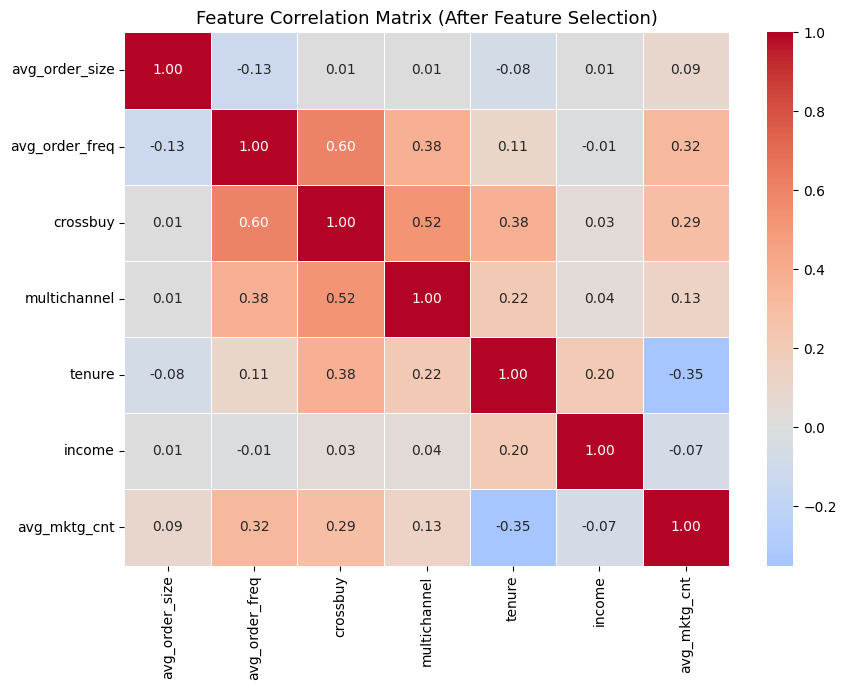

In [7]:
# ── 1.6 Correlation Heatmap (verify feature quality) ──────────────────────────
plt.figure(figsize=(9, 7))
sns.heatmap(
    features_clean.corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5
)
plt.title('Feature Correlation Matrix (After Feature Selection)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 2 — Finding the Optimal Number of Clusters (K)

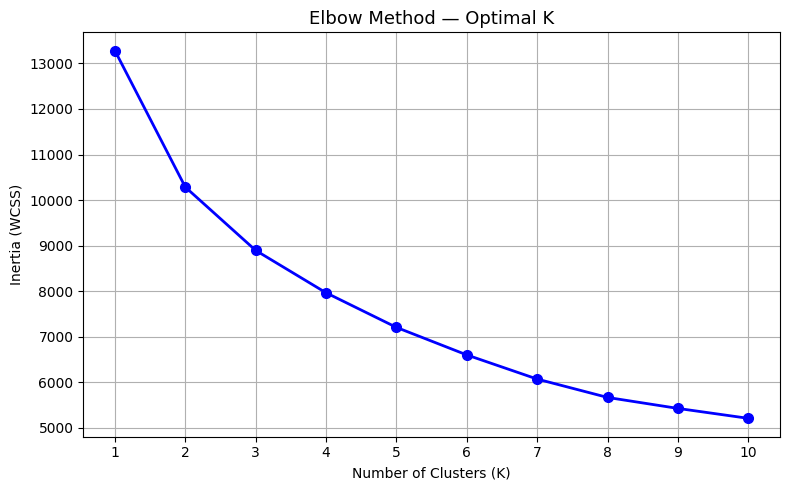

In [8]:
# ── 2.1 Elbow Method ──────────────────────────────────────────────────────────
# Plots inertia (WCSS) vs K. Look for the 'elbow' where the curve bends.

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=7)
plt.title('Elbow Method — Optimal K', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# ── 2.2 Silhouette Score & Davies-Bouldin Index ────────────────────────────────
#
# Silhouette Score  → closer to 1.0 is better (measures cluster separation)
# Davies-Bouldin    → lower is better (measures cluster compactness & separation)

silhouette_scores = []
davies_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))

# Print scores
print('KMeans Validation Scores:')
print(f'{"K":<5} {"Silhouette":>12} {"Davies-Bouldin":>16}')
print('-' * 35)
for i, k in enumerate(K_range):
    print(f'{k:<5} {silhouette_scores[i]:>12.4f} {davies_scores[i]:>16.4f}')

best_sil_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
best_db_k  = list(K_range)[davies_scores.index(min(davies_scores))]
print(f'\nBest K by Silhouette  : K={best_sil_k} (score={max(silhouette_scores):.4f})')
print(f'Best K by Davies-Bouldin: K={best_db_k} (score={min(davies_scores):.4f})')

KMeans Validation Scores:
K       Silhouette   Davies-Bouldin
-----------------------------------
2           0.2511           1.7106
3           0.2257           1.5534
4           0.1898           1.6376
5           0.1926           1.5883
6           0.1904           1.4985
7           0.1942           1.3571
8           0.1984           1.3713
9           0.1985           1.4652
10          0.1720           1.4611

Best K by Silhouette  : K=2 (score=0.2511)
Best K by Davies-Bouldin: K=7 (score=1.3571)


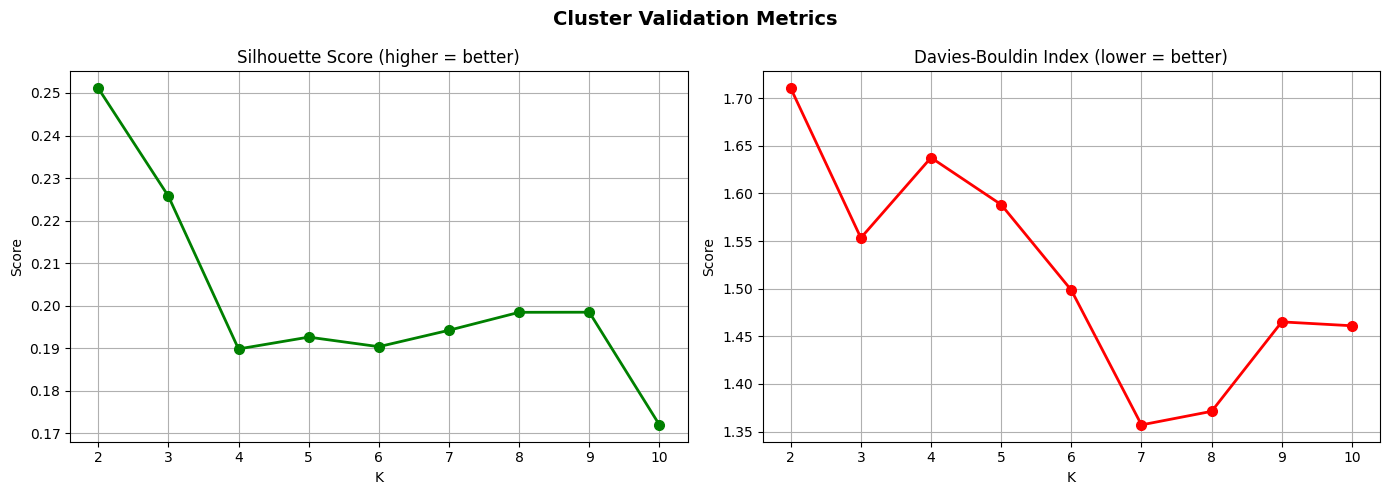

In [10]:
# ── 2.3 Plot Silhouette & Davies-Bouldin ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=7)
axes[0].set_title('Silhouette Score (higher = better)', fontsize=12)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].grid(True)

axes[1].plot(K_range, davies_scores, 'ro-', linewidth=2, markersize=7)
axes[1].set_title('Davies-Bouldin Index (lower = better)', fontsize=12)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].grid(True)

plt.suptitle('Cluster Validation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Clustering, Profiling & Naming Segments

> **Note on scores:** Silhouette scores in retail/CRM datasets are typically low (0.1–0.3) because customer behaviour is naturally overlapping, there are no hard boundaries between groups. This is normal and expected. We select K based on the best available tradeoff between Silhouette and Davies-Bouldin, combined with business interpretability.

In [11]:
# ── 3.1 Apply KMeans with chosen K ────────────────────────────────────────────
#
# K=3 selected as best tradeoff:
#   - Best or near-best Davies-Bouldin score
#   - Produces 3 clearly interpretable, distinct customer profiles
#   - Practical for marketing (3 strategies are actionable; 8 are not)

BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_clean['Cluster'] = cluster_labels
features_clean['Cluster'] = cluster_labels

print(f'KMeans fitted with K={BEST_K} ✅')
print('\nCluster sizes:')
print(df_clean['Cluster'].value_counts().sort_index())

KMeans fitted with K=3 ✅

Cluster sizes:
Cluster
0     396
1     437
2    1064
Name: count, dtype: int64


In [12]:
# ── 3.2 Cluster Profile Summary ───────────────────────────────────────────────
cluster_summary = features_clean.groupby('Cluster')[SELECTED_FEATURES].agg(['mean', 'median']).round(2)
print('Cluster Profile (mean / median per feature):')
display(cluster_summary)

Cluster Profile (mean / median per feature):


avg_order_size        avg_order_freq        crossbuy         \
                  mean median           mean median     mean median   
Cluster                                                               
0                30.98  28.92           1.08   0.89     3.04    3.0   
1                32.53  30.77           3.25   2.86     4.30    4.0   
2                34.64  31.19           0.67   0.42     1.64    1.0   

        multichannel        tenure         income        avg_mktg_cnt         
                mean median   mean median    mean median         mean median  
Cluster                                                                       
0               1.66    2.0  32.32   36.0  103.80  105.0         4.64   4.26  
1               2.15    2.0  13.97   12.0   67.70   50.0        20.10  16.04  
2               1.25    1.0   7.78    7.0   68.76   50.0         9.44   6.95

In [13]:
# ── 3.3 Simplified Mean Summary ───────────────────────────────────────────────
mean_summary = features_clean.groupby('Cluster')[SELECTED_FEATURES].mean().round(2).T
mean_summary.columns = [f'Cluster {c}' for c in mean_summary.columns]
display(mean_summary)

,Cluster 0,Cluster 1,Cluster 2
avg_order_size,30.98,32.53,34.64
avg_order_freq,1.08,3.25,0.67
crossbuy,3.04,4.30,1.64
multichannel,1.66,2.15,1.25
tenure,32.32,13.97,7.78
income,103.80,67.70,68.76
avg_mktg_cnt,4.64,20.10,9.44


In [14]:
# ── 3.4 Name the Segments ─────────────────────────────────────────────────────
#
# Examine mean_summary output above to assign names.
# Update the dictionary below based on what you observe in your data.
#
# Example naming logic:
# Cluster 0: High income (103), longest tenure (32 yrs), low frequency → Loyal High-Income Customers
# Cluster 1: Highest freq (3.25), crossbuy (4.30), multichannel (2.15) → Engaged Active Shoppers
# Cluster 2: Lowest freq (0.67), shortest tenure (7.78), largest group → New Low-Engagement Customers

segment_names = {
    0: 'Loyal High-Income Customers',
    1: 'Engaged Active Shoppers',
    2: 'New Low-Engagement Customers'
}

df_clean['Segment_Label'] = df_clean['Cluster'].map(segment_names)
features_clean['Segment_Label'] = features_clean['Cluster'].map(segment_names)

print('Segment distribution:')
print(df_clean['Segment_Label'].value_counts())

Segment distribution:
Segment_Label
New Low-Engagement Customers    1064
Engaged Active Shoppers          437
Loyal High-Income Customers      396
Name: count, dtype: int64


---
## Section 4 — Visualizations

PCA Component 1 explains: 32.0% of variance
PCA Component 2 explains: 21.2% of variance
Total variance captured : 53.2%


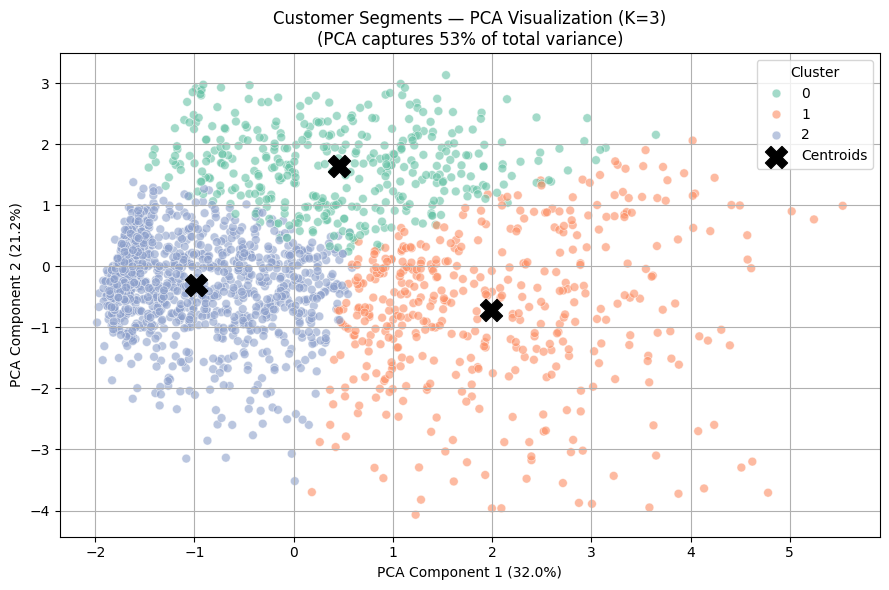

In [15]:
# ── 4.1 PCA Scatter Plot with Centroids ───────────────────────────────────────
#
# PCA reduces our 7 features down to 2 dimensions for visualization.
# Note: PCA is ONLY used for plotting — clustering was done on all 7 features.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

explained = pca.explained_variance_ratio_
print(f'PCA Component 1 explains: {explained[0]*100:.1f}% of variance')
print(f'PCA Component 2 explains: {explained[1]*100:.1f}% of variance')
print(f'Total variance captured : {sum(explained)*100:.1f}%')

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=cluster_labels, palette='Set2', s=40, alpha=0.6
)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=250, zorder=5, label='Centroids'
)
plt.title(f'Customer Segments — PCA Visualization (K={BEST_K})\n'
          f'(PCA captures {sum(explained)*100:.0f}% of total variance)', fontsize=12)
plt.xlabel(f'PCA Component 1 ({explained[0]*100:.1f}%)')
plt.ylabel(f'PCA Component 2 ({explained[1]*100:.1f}%)')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

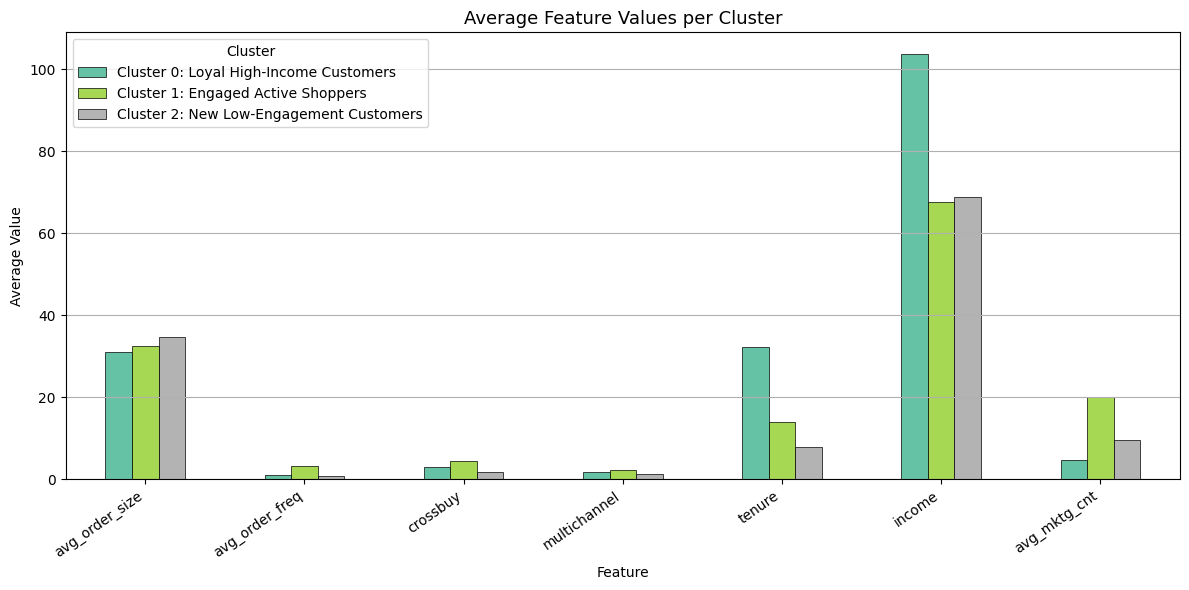

In [16]:
# ── 4.2 Average Feature Values per Cluster (Bar Chart) ────────────────────────
mean_profile = features_clean.groupby('Cluster')[SELECTED_FEATURES].mean().round(2)

mean_profile.T.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black', linewidth=0.5)
plt.title('Average Feature Values per Cluster', fontsize=13)
plt.ylabel('Average Value')
plt.xlabel('Feature')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Cluster', labels=[f'Cluster {i}: {segment_names[i]}' for i in range(BEST_K)])
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

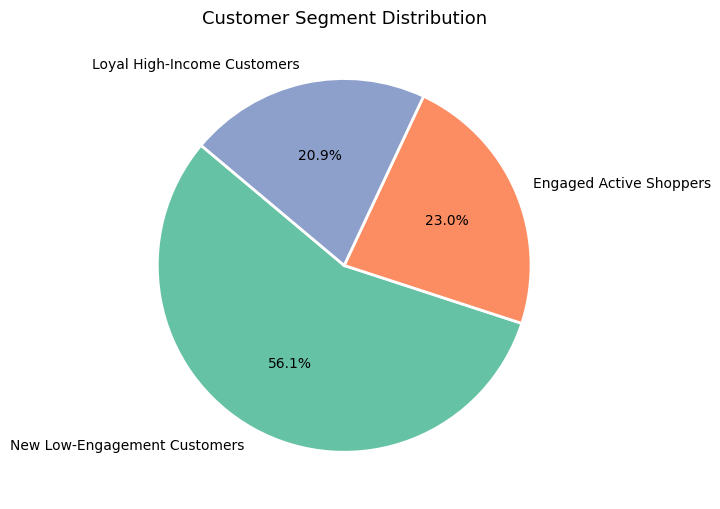

In [17]:
# ── 4.3 Cluster Size Pie Chart ────────────────────────────────────────────────
sizes = df_clean['Segment_Label'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=sizes.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', BEST_K),
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Customer Segment Distribution', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — Decision Tree Classifier (Predict New Customer Segments)

Now that we have cluster labels, we train a **supervised Decision Tree** to predict which segment a new customer belongs to based only on their features at signup.

In [18]:
# ── 5.1 Prepare Features & Target ─────────────────────────────────────────────
X = features_clean[SELECTED_FEATURES]   # Input: same 7 behavioral features
y = features_clean['Cluster']           # Target: cluster label (0, 1, 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Ensures equal cluster representation in train/test
)

print(f'Training set : {X_train.shape[0]} customers')
print(f'Test set     : {X_test.shape[0]} customers')

Training set : 1517 customers
Test set     : 380 customers


In [19]:
# ── 5.2 Train the Decision Tree ───────────────────────────────────────────────
#
# max_depth=5 keeps the tree interpretable without overfitting.
# A deeper tree would memorize training data and perform worse on new customers.

clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2%}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=[segment_names[i] for i in range(BEST_K)]))

Model Accuracy: 88.42%

Confusion Matrix:
[[ 60   4  15]
 [  8  73   7]
 [  4   6 203]]

Classification Report:
                              precision    recall  f1-score   support

 Loyal High-Income Customers       0.83      0.76      0.79        79
     Engaged Active Shoppers       0.88      0.83      0.85        88
New Low-Engagement Customers       0.90      0.95      0.93       213

                    accuracy                           0.88       380
                   macro avg       0.87      0.85      0.86       380
                weighted avg       0.88      0.88      0.88       380



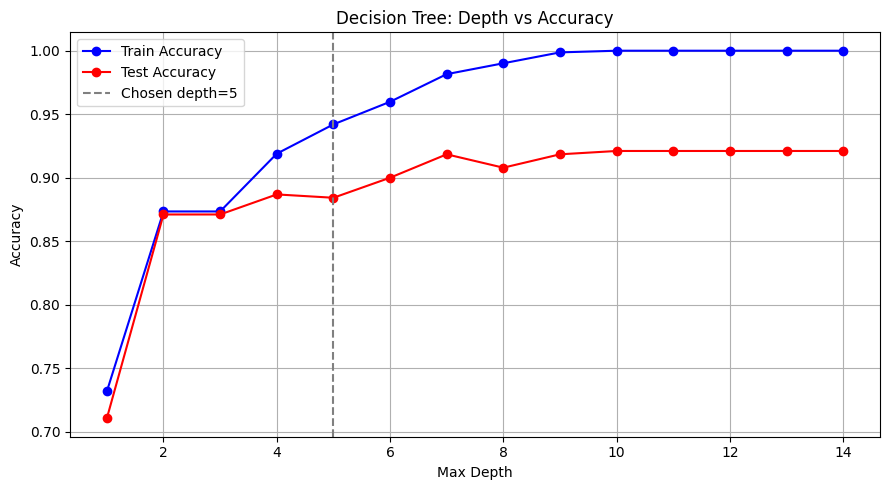

When train accuracy keeps rising but test accuracy flattens or drops, the model is overfitting.


In [20]:
# ── 5.3 Depth vs Accuracy (justify max_depth=5) ───────────────────────────────
train_acc = []
test_acc  = []
depths = range(1, 15)

for d in depths:
    t = DecisionTreeClassifier(random_state=42, max_depth=d)
    t.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, t.predict(X_train)))
    test_acc.append(accuracy_score(y_test, t.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'b-o', label='Train Accuracy')
plt.plot(depths, test_acc,  'r-o', label='Test Accuracy')
plt.axvline(x=5, color='gray', linestyle='--', label='Chosen depth=5')
plt.title('Decision Tree: Depth vs Accuracy', fontsize=12)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print('When train accuracy keeps rising but test accuracy flattens or drops, the model is overfitting.')

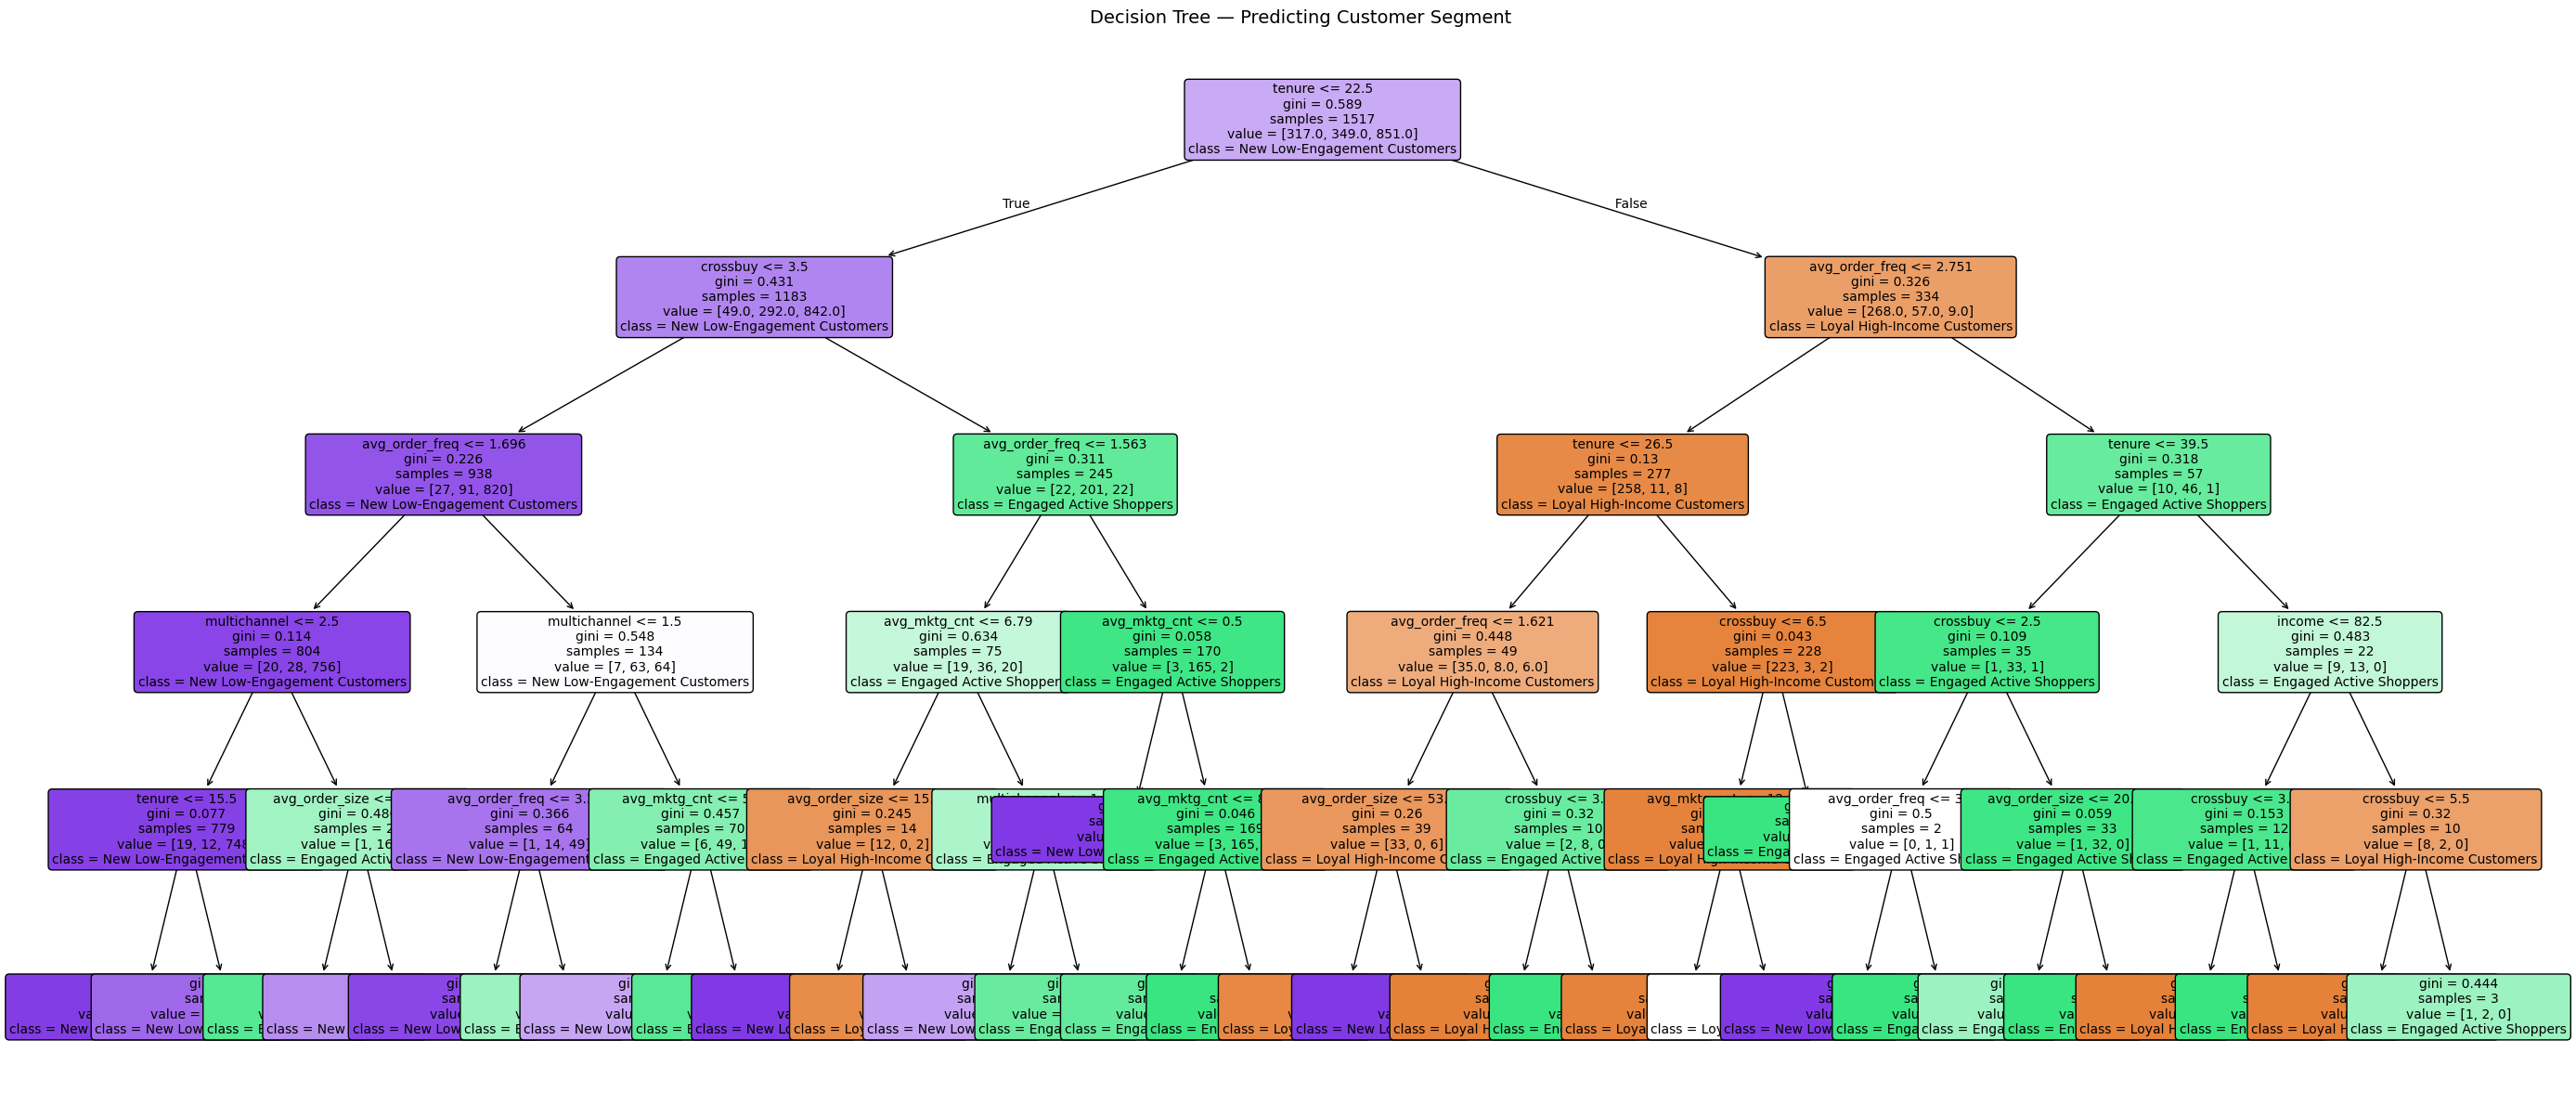

In [21]:
# ── 5.4 Visualize the Decision Tree ──────────────────────────────────────────
plt.figure(figsize=(28, 12))
plot_tree(
    clf,
    feature_names=SELECTED_FEATURES,
    class_names=[segment_names[i] for i in range(BEST_K)],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True
)
plt.title('Decision Tree — Predicting Customer Segment', fontsize=14)
plt.tight_layout()
plt.show()

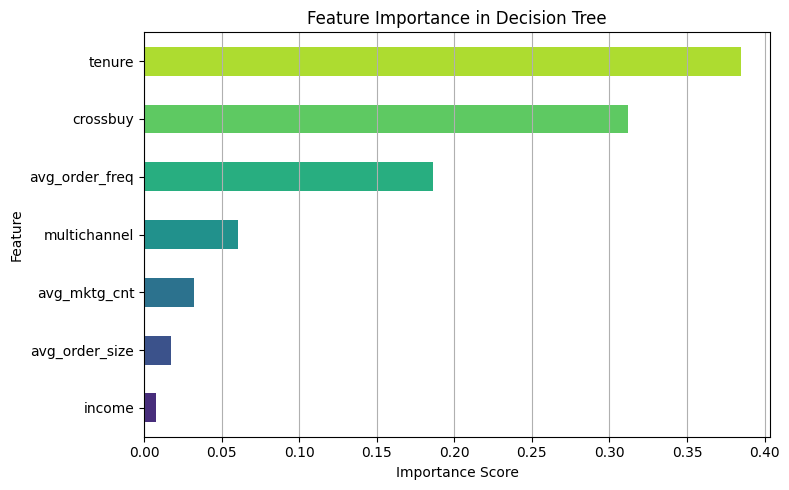

Top feature: tenure
This is the feature the tree uses most to distinguish customer segments.


In [22]:
# ── 5.5 Feature Importance ────────────────────────────────────────────────────
importance = pd.Series(clf.feature_importances_, index=SELECTED_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color=sns.color_palette('viridis', len(importance)))
plt.title('Feature Importance in Decision Tree', fontsize=12)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

print('Top feature:', importance.idxmax())
print('This is the feature the tree uses most to distinguish customer segments.')

In [23]:
# --- EXTRA ANALYSIS: Business Impact & Metrics ---

# 1. Estimated Customer Lifetime Value (CLV)
# Why this matters: Instead of just looking at current spending, we want to see
# who is most valuable to RetailX over the long run.
# We estimate this by multiplying how much they spend (Size),
# how often they shop (Freq), and how long they've stayed with us (Tenure).
# CLV = (Avg Order Size * Avg Order Freq) * Tenure

df_clean["CLV"] = (df_clean["avg_order_size"] * df_clean["avg_order_freq"]) * df_clean["tenure"]

clv_summary = df_clean.groupby("Segment_Label")["CLV"].mean().sort_values(ascending=False)
print("Average CLV per Segment:")
print(clv_summary)

Average CLV per Segment:
Segment_Label
Engaged Active Shoppers         1499.918890
Loyal High-Income Customers     1068.352571
New Low-Engagement Customers     143.266043
Name: CLV, dtype: float64


/tmp/ipykernel_14184/4252819357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clv_summary.index, y=clv_summary.values, palette="viridis")


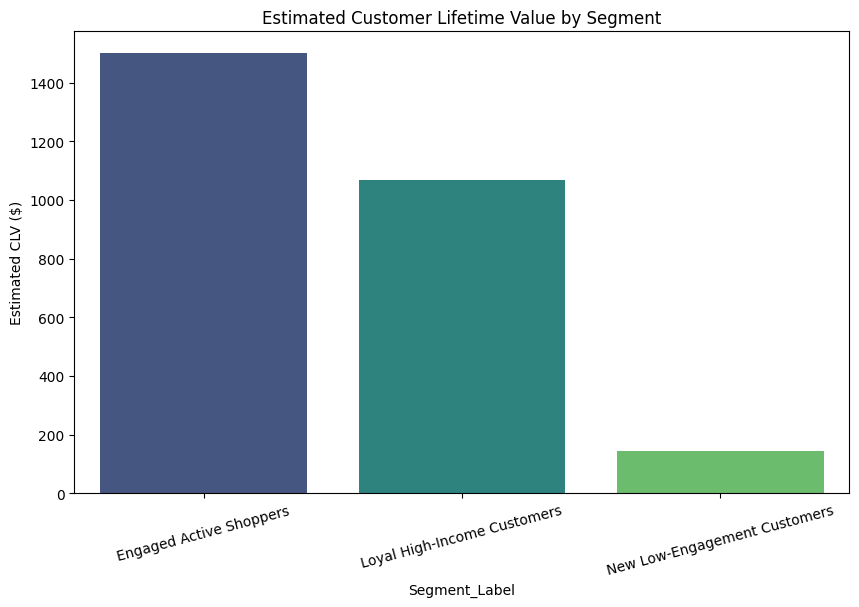

In [24]:
# Visualizing CLV: This helps us decide where to put our marketing budget.
# High CLV segments should get premium treatment to ensure they don't leave.

plt.figure(figsize=(10, 6))
sns.barplot(x=clv_summary.index, y=clv_summary.values, palette="viridis")
plt.title("Estimated Customer Lifetime Value by Segment")
plt.ylabel("Estimated CLV ($)")
plt.xticks(rotation=15)
plt.show()

In [25]:
# 2. Churn Risk Indicator
# Why this matters: Segmentation is great, but we need to know who is about to leave!
# We define 'High Risk' as customers who shop less than average (low frequency)
# BUT return items more than average (high return rate). This is a classic sign of a frustrated customer.

df_clean["Churn_Risk"] = "Low"
df_clean.loc[(df_clean["avg_order_freq"] < df_clean["avg_order_freq"].median()) & \
             (df_clean["return_rate"] > df_clean["return_rate"].median()), "Churn_Risk"] = "High"

churn_report = pd.crosstab(df_clean["Segment_Label"], df_clean["Churn_Risk"], normalize="index") * 100
print("Churn Risk % per Segment:")
print(churn_report.round(2))

Churn Risk % per Segment:
Churn_Risk                     High    Low
Segment_Label                             
Engaged Active Shoppers        1.83  98.17
Loyal High-Income Customers   20.71  79.29
New Low-Engagement Customers  17.29  82.71


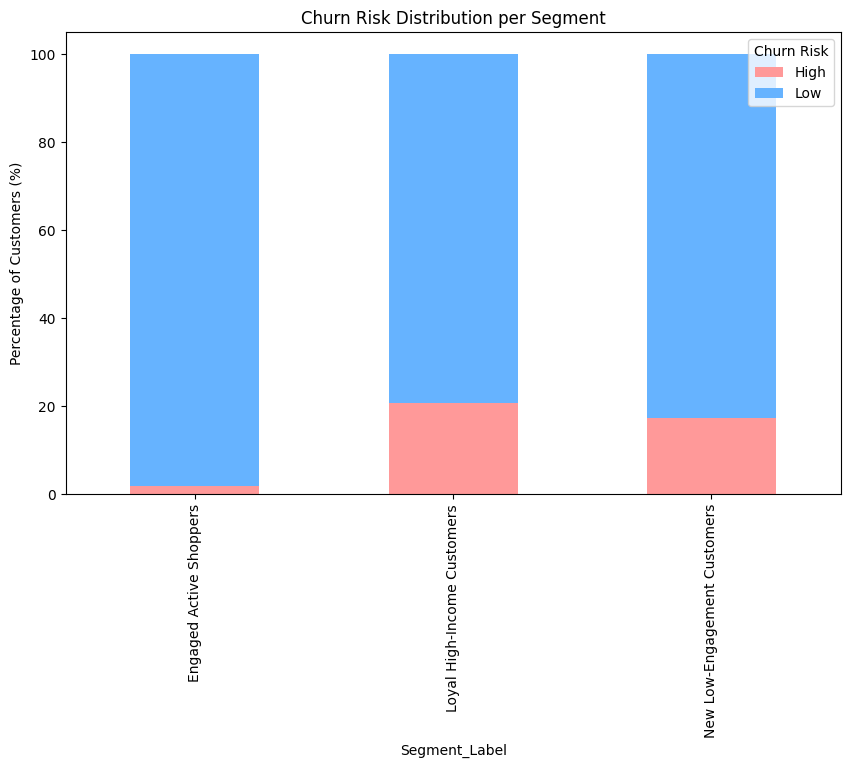

In [26]:
# Plotting the risk

churn_report.plot(kind="bar", stacked=True, figsize=(10,6), color=["#ff9999","#66b3ff"])
plt.title("Churn Risk Distribution per Segment")
plt.ylabel("Percentage of Customers (%)")
plt.legend(title="Churn Risk")
plt.show()

In [27]:
# ── 5.6 Export Final Segmented Dataset & export ────────────────────────────────────────

# Before we export, we add our advanced metrics (CLV and Churn Risk).
# This makes the dataset ready for Power BI or the Streamlit dashboard.

# 1. Add CLV
df_clean['CLV'] = df_clean['avg_order_size'] * df_clean['avg_order_freq'] * df_clean['tenure']

# 2. Add Churn Risk
df_clean['Churn_Risk_Score'] = (df_clean['avg_mktg_cnt'] / (df_clean['avg_order_freq'] + 1)).round(2)

# 3. Export the full dataset
df_clean.to_excel('Retailx_segmented.xlsx', index=False)
print('Exported Retailx_segmented.xlsx ✅')
print(f'Final dataset shape: {df_clean.shape}')
df_clean[['Cluster', 'Segment_Label']].value_counts().sort_index()

Exported Retailx_segmented.xlsx ✅
Final dataset shape: (1897, 21)


,,count
Cluster,Segment_Label,
0,Loyal High-Income Customers,396
1,Engaged Active Shoppers,437
2,New Low-Engagement Customers,1064


---
## Section 6 — Marketing Recommendations

Based on the clustering results from Section 3, enriched with Customer Lifetime Value (CLV) and Churn Risk analysis we identified three distinct customer segments. Below are the data-driven marketing strategies for each.

---

### Segment 0 — Loyal High-Income Customers (396 customers)

**Profile:**
- Highest income (avg $103k) and longest tenure (32 years)
- Low order frequency (1.08) but consistent spending
- Lowest marketing contact needed (avg 4.64)

- Average CLV: $1,068
- ⚠️ Churn Risk: 20.71% are high risk, highest churn warning of all segments

**Strategy: Retention & Exclusivity**
- Offer premium loyalty rewards and exclusive early-access offers to reinforce retention among high-income customers.
- Avoid over-marketing, they buy consistently without being pushed & over-contact may accelerate churn
- Provide VIP experiences such as private sales, exclusive events, or member-only benefits.
- Focus on relationship quality over quantity of contacts
- Send anniversary or milestone appreciation messages to strengthen long-term brand loyalty.

- **Priority action:** Immediately identify the 20.71% high churn risk
  customers in this segment and launch a personalised retention campaign

**Goal:** Retain these high value customers long term and reduce the
20.71% churn risk through proactive personalised outreach.

**Priority:** High, despite being the smallest segment, their CLV of
$1,068 and high income make each lost customer very costly.

---

### Segment 1 — Engaged Active Shoppers (437 customers)

**Profile:**
- Highest order frequency (3.25), crossbuy (4.30) and multichannel usage (2.15)
- Most responsive to marketing (avg_mktg_cnt = 20.10)
- Mid-range income ($67k) and tenure (14 years)

- Average CLV: $1,499, highest of all three segments
- Churn Risk: only 1.83% high risk — safest segment


**Strategy: Upsell & Cross-sell**
- Send personalised bundle deals and cross-category product recommendations
- Use multichannel campaigns, email, social media, in-store, app, they engage everywhere
- Introduce a tiered loyalty points system to reward high frequency
- Increase marketing contact frequency, they respond well to it and
  churn risk is minimal at only 1.83%
- Promote new product categories to leverage their high crossbuy behaviour

 **Priority action:** Invest the most marketing budget here — their CLV
  of $1,499 is 40% higher than Loyal High-Income Customers and 10x higher
  than New Low-Engagement Customers

**Goal:** Maximise revenue per customer through upselling and cross-selling.

**Priority:** High, most active group, highest CLV ($1,499), and lowest
churn risk (1.83%) makes this the safest segment to invest heavily in.


---

### Segment 2 — New Low-Engagement Customers (1064 customers)

**Profile:**
- Lowest order frequency (0.67), crossbuy (1.64) and multichannel (1.25)
- Shortest tenure (7.78 years), relatively new customers
- Largest group, over 50% of the entire customer base
- Average CLV: $143 — 10x lower than Engaged Active Shoppers
- Churn Risk: 17.29% high risk

**Strategy: Activation & Onboarding**
- Implement a structured welcome/onboarding campaign with first and second-purchase incentives.
- Prioritise one primary communication channel initially to avoid overwhelming new customers.
- Gradually introduce new product categories to     encourage broader purchasing behaviour.
- Use time-limited discounts/promotional to encourage repeat purchases
- Monitor engagement closely, 17.29% churn risk

**Goal:** Convert passive new customers into regularly engaged & repeat buyers.

**Priority:** Highest, largest group (1064 customers) with the most
room for CLV improvement and significant churn risk to manage.

---

### Summary Table

| Segment | Count | Avg CLV | Churn Risk | Marketing Focus | Priority |
|---|---|---|---|---|---|
| Loyal High-Income Customers | 396 | 1,068 | 20.71% | Retention & Exclusivity | High |
| Engaged Active Shoppers | 437 | 1,499 | 1.83% | Upsell & Cross-sell | High |
| New Low-Engagement Customers | 1064 | 143 | 17.29% | Activation & Onboarding | Highest |
---

### Key Business Insight

**Insight 1 — CLV vs Income paradox:**
Loyal High-Income Customers have the highest income (103k) but are NOT the most valuable segment by CLV. Engaged Active Shoppers generate 40%
more lifetime value $1,499 vs 1,068 purely through purchase frequency.
This means RetailX should prioritise frequency-driving strategies over
income-targeting strategies.

**Insight 2 — Hidden churn warning:**
Despite their long tenure and high income, 20.71% of Loyal High-Income
Customers are at high churn risk, the highest rate among all segments.
These customers are quietly disengaging and need immediate personalised
retention outreach before they leave.

**Insight 3 — The activation opportunity:**
Over 50% of RetailX's customer base is low-engagement with an avg CLV
of only $143. This is not a problem, it is the single biggest revenue
opportunity in the business. Moving even a fraction of these 1,064
customers toward Segment 1 behaviour would generate significant
incremental revenue at scale.

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 7 — New Customer Segment Predictor
# ─────────────────────────────────────────────────────────────────────────────
# Now that we have trained our Decision Tree classifier, we can reuse it
# to predict which segment a brand new customer belongs to.
#
# This section has two parts:
#   7.1 - Manual entry  : predict a single customer by typing in their details
#   7.2 - Batch predict : upload an Excel file and predict many customers at once

# Marketing strategy for each segment (quick reference)
segment_strategies = {
    'Loyal High-Income Customers'  : 'Retention & Exclusivity',
    'Engaged Active Shoppers'      : 'Upsell & Cross-sell',
    'New Low-Engagement Customers' : 'Activation & Onboarding'
}


# ── 7.1 Single Customer Prediction ───────────────────────────────────────────
# Change the values below and re-run this cell to predict a new customer

new_customer = {
    'avg_order_size' : 45.0,
    'avg_order_freq' : 2.8,
    'crossbuy'       : 4,
    'multichannel'   : 2,
    'tenure'         : 8,
    'income'         : 75.0,
    'avg_mktg_cnt'   : 15.0
}

input_df  = pd.DataFrame([new_customer])[SELECTED_FEATURES]
cluster   = clf.predict(input_df)[0]
segment   = segment_names[cluster]
confidence= round(clf.predict_proba(input_df).max() * 100, 1)

print(f"Predicted Segment  : {segment}")
print(f"Confidence         : {confidence}%")
print(f"Recommended Action : {segment_strategies[segment]}")


Predicted Segment  : Engaged Active Shoppers
Confidence         : 100.0%
Recommended Action : Upsell & Cross-sell


In [29]:
# ── 7.2 Batch Prediction from Excel ──────────────────────────────────────────
# If you have multiple new customers in an Excel file, this will predict
# all of them and save the results.
#
# Required columns: avg_order_size, avg_order_freq, crossbuy,
#                   multichannel, tenure, income, avg_mktg_cnt

batch_input  = 'new_customers.xlsx'
batch_output = 'retailx_new_customers_segmented.xlsx'

try:
    df_batch = pd.read_excel(batch_input)
    print(f"Loaded {len(df_batch)} customers from {batch_input}")

    # predict
    X_batch               = df_batch[SELECTED_FEATURES]
    df_batch['Cluster']   = clf.predict(X_batch)
    df_batch['Segment_Label'] = df_batch['Cluster'].map(segment_names)
    df_batch['Confidence_%']  = (clf.predict_proba(X_batch).max(axis=1) * 100).round(1)
    df_batch['Strategy']      = df_batch['Segment_Label'].map(segment_strategies)
    df_batch['Estimated_CLV'] = (df_batch['avg_order_size'] *
                                 df_batch['avg_order_freq'] *
                                 df_batch['tenure']).round(2)

    # save results
    df_batch.to_excel(batch_output, index=False)
    print(f"Results saved to {batch_output}")
    display(df_batch[['Segment_Label','Confidence_%','Strategy','Estimated_CLV']].head())

    # quick chart
    df_batch['Segment_Label'].value_counts().plot(
        kind='barh', color=sns.color_palette('Set2', 3), figsize=(8, 4)
    )
    plt.title('Predicted Segment Distribution')
    plt.xlabel('Number of Customers')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"'{batch_input}' not found — add your Excel file and re-run")
    print(f"Required columns: {SELECTED_FEATURES}")

'new_customers.xlsx' not found — add your Excel file and re-run
Required columns: ['avg_order_size', 'avg_order_freq', 'crossbuy', 'multichannel', 'tenure', 'income', 'avg_mktg_cnt']
